# Running DASK for Week 8

Edited by Yangyu Wang (Developed from Wonje Yun, Adam Wu)

## 1. Running DASK on AWS EC2

To run DASK on AWS EC2, we need to install dask cloud provider to launch the EC2 instance, and controll it locally.
To install dask cloud provider, we need to install the package in either way:

```bash
# use conda
$ conda install -c conda-forge dask-cloudprovider
```

After installing the package, make sure to update the credentials, since we are still using AWS EC2.

In [4]:
from dask_cloudprovider.aws import EC2Cluster 
from dask.distributed import Client
import configparser
import os
import contextlib
import re
import dask
from platform import python_version

In [6]:
# We need this function to get the AWS credentials from the config file to pass to the EC2Cluster

def get_aws_credentials():
    """Read in your AWS credentials file and convert to environment variables."""
    parser = configparser.RawConfigParser()
    
    parser.read(os.path.expanduser('~/.aws/config'))
    config = parser.items('default')
    
    parser.read(os.path.expanduser('~/.aws/credentials'))
    credentials = parser.items('default')
    
    all_credentials = {key.upper(): value for key, value in [*config, *credentials]}
    with contextlib.suppress(KeyError):
        all_credentials["AWS_REGION"] = all_credentials.pop("REGION")
        
    return all_credentials

In [7]:
# Pass in AWS Credentials + any extra packages you would like to install on cluster via `pip`
env_vars = get_aws_credentials()
env_vars["EXTRA_PIP_PACKAGES"] = "s3fs" # we are going to install s3fs library on the cluster

# Select software installed on scheduler + worker instances based on client Python + Dask versions
# versions need to match across client, scheduler, worker -- slight mismatches are OK, though
py_v = '-py' + re.findall(r'\d{1}.\d+', python_version())[0] # find the python version
dask_docker_tag = f"daskdev/dask:{dask.__version__ + py_v}" # get the dask docker tag that matches the client version
print('Docker Image: ', dask_docker_tag)

Docker Image:  daskdev/dask:2026.3.0-py3.10


If you run EC2Cluster without the vpc, subnet and security groups, and face certain errors, you could run [`security_group_setting.bash`](./security_group_setting.bash) in your terminal and insert the ids.

In [ ]:
# launch a cluster of 5 r5.large instances (10 vCPUs):
# 1 scheduler
# 4 workers (2 threads + 16 GB RAM each)
cluster = EC2Cluster(
                    instance_type="r5.large",
                    n_workers=4,
                    security=False,
                    docker_image=dask_docker_tag,
                    env_vars=env_vars,
                    vpc="vpc-...", # replace with your VPC ID
                    subnet_id="subnet-...", # replace with your subnet ID
                    security_groups=["sg-..."], # replace with your security group IDs
)

Creating scheduler instance
Created instance i-082979f4c3d3ce367 as dask-7c602a28-scheduler
Waiting for scheduler to run at 54.80.108.71:8786
Scheduler is running


/Users/yangyu/anaconda3/envs/macs30123/lib/python3.10/contextlib.py:142: UserWarning: Creating your cluster is taking a surprisingly long time. This is likely due to pending resources. Hang tight! 
  next(self.gen)


Creating worker instance
Creating worker instance
Creating worker instance
Creating worker instance
Created instance i-091eb37f96325767a as dask-7c602a28-worker-934b6325
Created instance i-0643106d10f0fe234 as dask-7c602a28-worker-4fba9b94
Created instance i-08445e1de94e97fc3 as dask-7c602a28-worker-b0cd92ac
Created instance i-0eb03d1172656eb34 as dask-7c602a28-worker-fd0c0dce


2026-05-16 11:36:07,826 - distributed.deploy.cluster - WARNING - Failed to sync cluster info multiple times - perhaps there's a connection issue? Error:
Traceback (most recent call last):
  File "/Users/yangyu/anaconda3/envs/macs30123/lib/python3.10/site-packages/distributed/comm/tcp.py", line 547, in connect
    stream = await self.client.connect(
  File "/Users/yangyu/anaconda3/envs/macs30123/lib/python3.10/site-packages/tornado/tcpclient.py", line 279, in connect
    af, addr, stream = await connector.start(connect_timeout=timeout)
asyncio.exceptions.CancelledError

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/yangyu/anaconda3/envs/macs30123/lib/python3.10/asyncio/tasks.py", line 456, in wait_for
    return fut.result()
asyncio.exceptions.CancelledError

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/yangyu/anaconda3/envs/macs30123/lib/py

In [9]:
client = Client(cluster)
client # note that slight mismatches between client, scheduler, and worker software are fine

/Users/yangyu/anaconda3/envs/macs30123/lib/python3.10/site-packages/distributed/client.py:1607: VersionMismatchWarning: Mismatched versions found

+---------+--------+-----------+---------+
| Package | Client | Scheduler | Workers |
+---------+--------+-----------+---------+
| msgpack | 1.1.1  | 1.1.2     | None    |
+---------+--------+-----------+---------+
  warnings.warn(version_module.VersionMismatchWarning(msg[0]["warning"]))


Connection method: Cluster object,Cluster type: dask_cloudprovider.EC2Cluster
Dashboard: http://54.80.108.71:8787/status,
Dashboard: http://54.80.108.71:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.31.34.95:8786,Workers: 0
Dashboard: http://172.31.34.95:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


2026-05-16 11:33:55,169 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


## 2. Running DASK on Local Machine

You can install dask on your local machine using pip.

```bash
$ pip install dask
```

Also, to visualize the dask graph, you can install graphviz.

```bash
$ pip install graphviz
```

### 2-1. Graphviz Installation

If graphviz cannot be installed, look [here](https://stackoverflow.com/questions/73830695/failed-to-execute-posixpathdot-make-sure-the-graphviz-executables-are-on-y) for help.

#### 2-1-1. For macOS, follow the steps:

1. Install grpahviz using brew:
```bash
brew install graphviz
```

2. To test if graphviz is installed, run the following command:
```bash
$ dot -V
```

#### 2-1-2. For Windows:

1. Download the graphviz installer from [here](https://graphviz.gitlab.io/_pages/Download/Download_windows.html).

2. Install the downloaded file.

3. Add the path to the environment variable:
```bash
C:\Program Files\Graphviz\bin
```

4. To test if graphviz is installed, run the following command:
```bash
$ dot -V
```

Or look [here](https://stackoverflow.com/questions/45092771/how-to-install-graphviz-2-38-on-windows-10) for more information.


In [10]:
import dask
from dask.distributed import Client

In [11]:
client = Client()
client # note that slight mismatches between client, scheduler, and worker software are fine

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 5
Total threads: 15,Total memory: 24.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:54842,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:54855,Total threads: 3
Dashboard: http://127.0.0.1:54864/status,Memory: 4.80 GiB
Nanny: tcp://127.0.0.1:54845,


In [12]:
def inc(x):
    return x + 1

def double(x):
    return x * 2

def add(x, y):
    return x + y

data = range(4)

output = []
for x in data:
    a = dask.delayed(inc)(x)
    b = dask.delayed(double)(x)
    c = dask.delayed(add)(a, b)
    output.append(c)

total = dask.delayed(sum)(output)

In [13]:
total.compute()

22

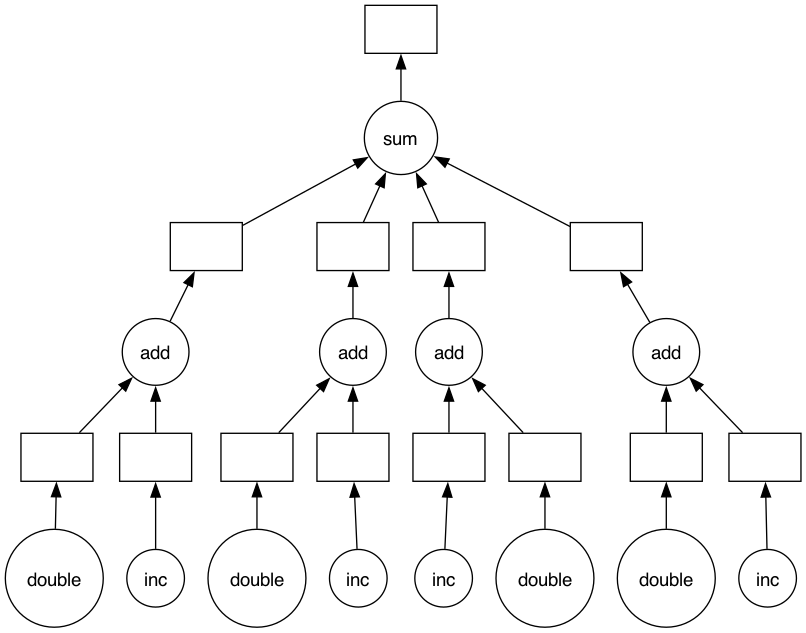

In [14]:
total.visualize() # can use format='svg' if the graph is too large

## 3. Running DASK on Midway Cluster

For launching jupuyter lab on Midway, refer to [Midway Jupyter Guide](https://rcc-uchicago.github.io/user-guide/software/apps-and-envs/python/?h=jupyter#running-jupyterlab)

1. login to Midway3 using ssh
2. Load the python module and install required packages ti request Midway cluster for Dask cluster
```bash
$ module load python
$ pip install --user dask[complete]==2022.7.0 dask-jobqueue==0.7.4 dask-ml==2022.5.27
```
3. Determine the IP address
```bash
$ HOST_IP=`/sbin/ip route get 8.8.8.8 | awk '{print $7;exit}'`
$ echo $HOST_IP
```
4. Launch Jupyter Lab
```bash
$ jupyter lab --no-browser --ip=$HOST_IP --port=15021 # the port number can be any number
```
5. Cpoy the URL and paste it in your local browser; if it does not work, use `ssh` as we did for pyspark.
6. To shutdown the Jupyter Lab, press `Ctrl + C` in the terminal (for both windows and mac)

From the Jupyter Lab, you can access the files in your Midway account and run the DASK ipython code provided in `in-class-activities/08_Dask/8M_Intro/dask_ml_midway.ipynb`